In [22]:
# auto reload modules
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [23]:
import matplotlib.pyplot as plt
from cns.process.binning import group_bins, sum_cns
from cns.utils.selection import get_cns_for_type, only_aut
from cns.display.plot import fig_lines, plot_lines
from cns.data_utils import main_load_data, select_CNS_samples, load_merged_samples

In [24]:
load_merged_samples(True);

PCAWG
Total samples: 2778
225 samples are CN neutral
12 samples have low coverage
195 samples are blacklisted
Filtered samples: 2374
TRACERx
Total samples: 1428
0 samples are CN neutral
8 samples have low coverage
248 samples do not have exact type
Filtered samples: 1172
TCGA_hg19
Total samples: 9868
948 samples are CN neutral
46 samples have low coverage
Filtered samples: 8874
Overlapping samples with PCAWG: 748
After overlap removal: 8261
Total samples: 11807


In [32]:
samples_df, cns_df = main_load_data("1MB")
# cns_df = load_merged_bins(samples_df, "3MB")

In [26]:
samples_df["type"].value_counts().head(6).sum()

4669

Text(0.5, 1.0, 'The joint set of 11807 samples')

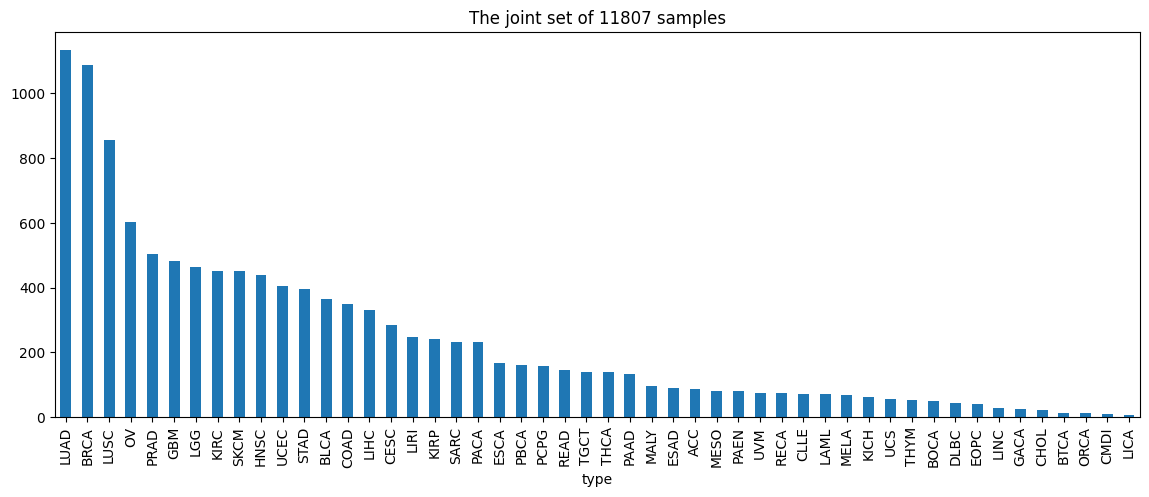

In [27]:
plt.rcParams["figure.figsize"] = (14,5)
samples_df["type"].value_counts().plot(kind="bar")
plt.title("The joint set of {} samples".format(len(samples_df)))

In [28]:
sel = get_cns_for_type(cns_df, samples_df, "LUAD")
group_bins(sel)

,cum_mid,chrom,start,end,mid,length,major_cn,minor_cn,total_cn
0,1482139,chr1,0,2964279,1482139,2964279,1.953309,1.098913,3.052223
1,4446418,chr1,2964279,5928558,4446418,2964279,1.868505,1.083610,2.952115
2,7410697,chr1,5928558,8892837,7410697,2964279,1.835416,1.080049,2.915464
3,10374976,chr1,8892837,11857116,10374976,2964279,1.837565,1.097266,2.934830
4,13339255,chr1,11857116,14821394,13339255,2964278,1.857718,1.098683,2.956400
...,...,...,...,...,...,...,...,...,...
957,3054122841,chrY,16247515,19390476,17818995,3142961,0.027634,0.000000,0.027634
958,3057265803,chrY,19390476,22533438,20961957,3142962,0.027634,0.000000,0.027634
959,3060408764,chrY,22533438,25676399,24104918,3142961,0.027634,0.000000,0.027634
960,3063551726,chrY,25676399,28819361,27247880,3142962,0.027634,0.000000,0.027634


In [29]:
top_6 = samples_df["type"].value_counts().head(6).index
top_6_cns_df = [group_bins(get_cns_for_type(cns_df, samples_df, cancer_type)) for cancer_type in top_6]

Text(0.5, 1.0, 'Mean total copy number for the top 6 cancer types')

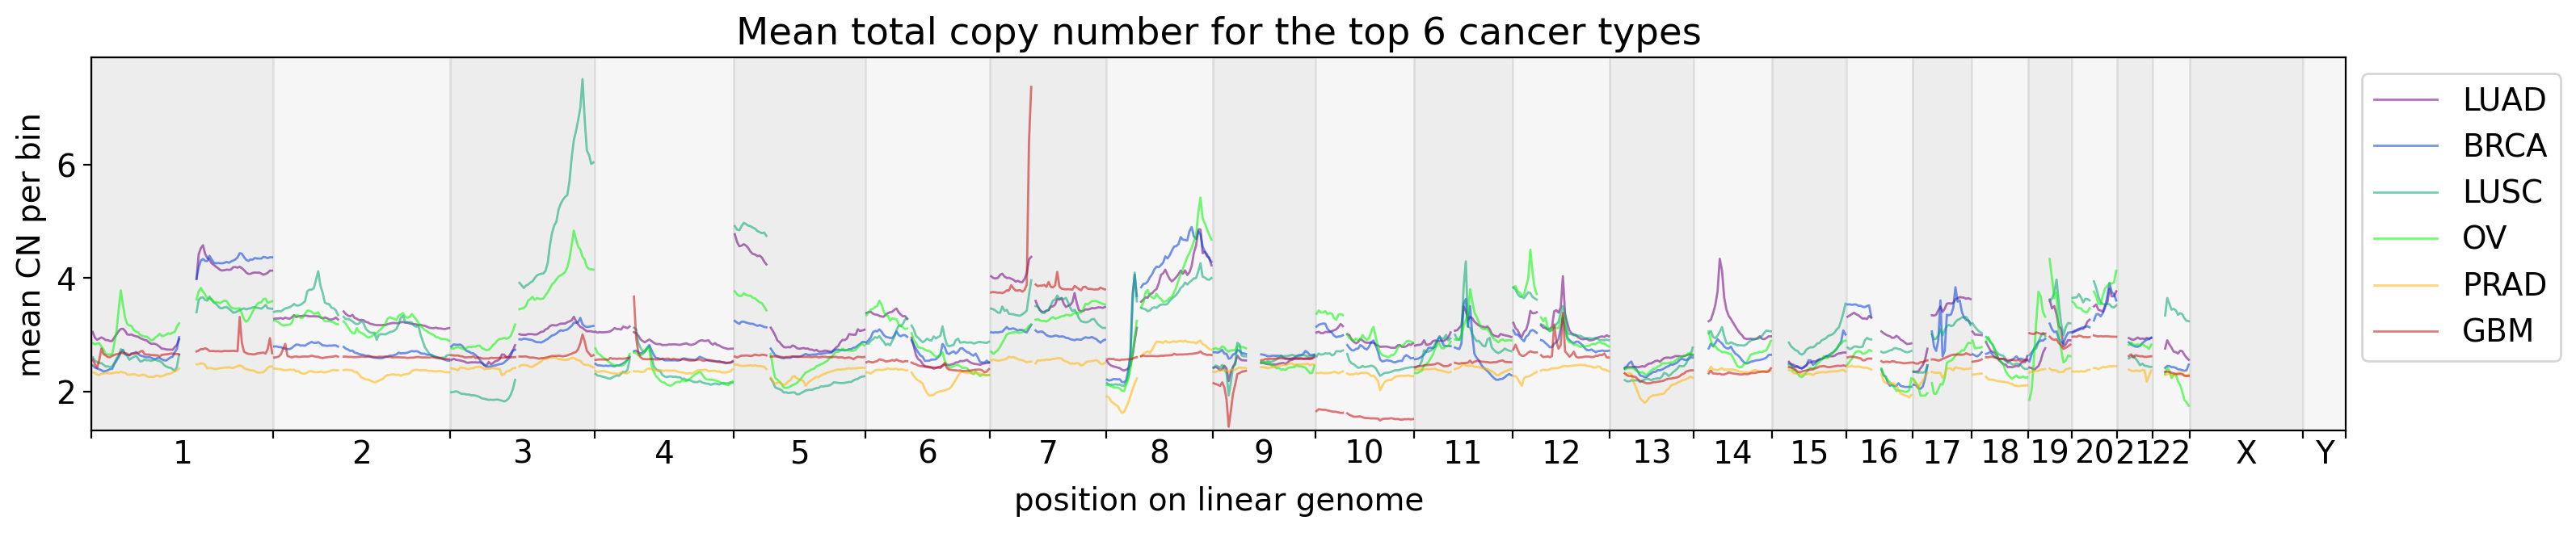

In [33]:
# double font size
plt.rcParams["font.size"] = 14
fig_lines([only_aut(x) for x in top_6_cns_df], top_6, column="total_cn", dpi=200)
# add title
plt.title("Mean total copy number for the top 6 cancer types")

(<Figure size 1800x300 with 1 Axes>,
 <Axes: xlabel='position on linear genome', ylabel='mean CN per bin'>)

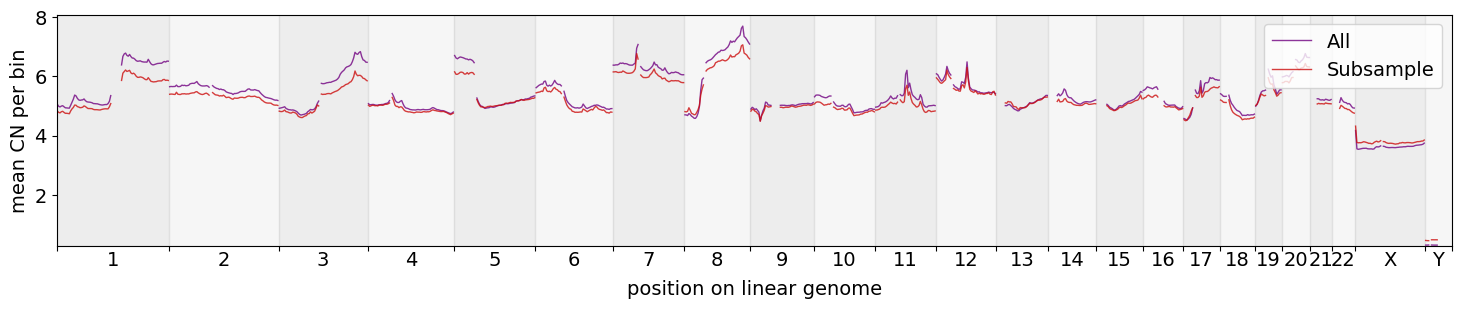

In [31]:
above_50 = samples_df["type"].value_counts().where(lambda x: x >= 50).where(lambda x: x != "Other").dropna().index.values
all_samples = samples_df.query("type in @above_50")
sub_samples = all_samples.groupby('type').apply(lambda x: x.sample(n=50, replace=True) if len(x) > 50 else x, include_groups=False).reset_index().set_index('sample_id')
# select only 50 samples for each type to obtain balanced mean
selection = [sum_cns(group_bins(select_CNS_samples(cns_df, samples))) for samples in [all_samples, sub_samples]]
fig_lines(selection, ["All", "Subsample"], column="total_cn", dpi=100)
